# EDA of Kidney Disease Patient Data
This notebook explores the data set that was generated for patients with kidney disease. Recall that 1000 patients were randomly sampled from those with kidney disease and all lab measurements for these patients was extracted from `labevents.csv`. We begin by loading this lab measurement data.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

In [8]:
kidney_disease_df = pd.read_csv('../Data/kidney_disease_random_1000_patients.csv.gz', 
                               compression = 'gzip')
kidney_disease_df.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,917899,10061124,24090860.0,19944894,50868,NaN,2168-08-03 19:30:00,2168-08-03 20:03:00,11,11.0,mEq/L,8.0,20.0,NaN,STAT,NaN
1,917900,10061124,24090860.0,19944894,50882,NaN,2168-08-03 19:30:00,2168-08-03 20:03:00,28,28.0,mEq/L,22.0,32.0,NaN,STAT,NaN
2,917901,10061124,24090860.0,19944894,50902,NaN,2168-08-03 19:30:00,2168-08-03 20:03:00,106,106.0,mEq/L,96.0,108.0,NaN,STAT,NaN
3,917902,10061124,24090860.0,19944894,50912,NaN,2168-08-03 19:30:00,2168-08-03 20:03:00,1.3,1.3,mg/dL,0.5,1.2,abnormal,STAT,NaN
4,917903,10061124,24090860.0,19944894,50920,NaN,2168-08-03 19:30:00,2168-08-03 20:03:00,NaN,NaN,NaN,NaN,NaN,NaN,STAT,"Using this patient's age, gender, and serum cr..."


One lab measurement of particular interest is serum creatinine (`itemid` = 50912). For patients with kidney disease, this value is expected to be abnormally high. Below we perform two checks on the validity of the previous remark:
1. Create a histogram of the serum creatinine lab measurements.
2. Calculate summary statistics for this lab measurment. 

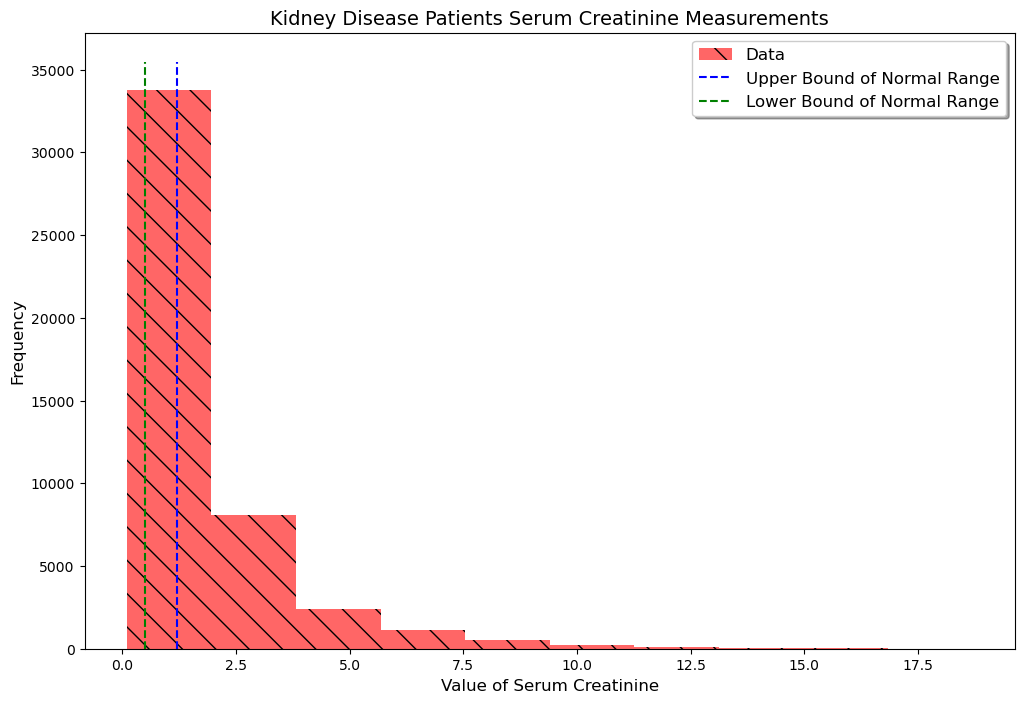

In [104]:
serum_creatinine_labs = kidney_disease_df.loc[kidney_disease_df['itemid'] == 50912]
serum_creatinine_lb = np.max(serum_creatinine_labs['ref_range_lower'])
serum_creatinine_ub = np.max(serum_creatinine_labs['ref_range_upper'])
plt.figure(figsize = (12, 8))
n, bins, patches = plt.hist(serum_creatinine_labs['valuenum'],
        color = 'red',
        hatch = '\\',
        alpha = 0.6,
        label = 'Data')
plt.plot([serum_creatinine_ub, serum_creatinine_ub],
        [0, 1.05*np.max(n)],
        'b--',
        label = 'Upper Bound of Normal Range')
plt.plot([serum_creatinine_lb, serum_creatinine_lb],
        [0, 1.05*np.max(n)],
        'g--',
        label = 'Lower Bound of Normal Range')
plt.xlabel('Value of Serum Creatinine',
          fontsize = 12)
plt.ylabel('Frequency',
          fontsize = 12)
plt.title('Kidney Disease Patients Serum Creatinine Measurements', 
         fontsize = 14)
plt.legend(loc = 'upper right',
          fancybox = True,
          shadow = True,
          fontsize = 12)
plt.show()

In [93]:
n_high_labs = serum_creatinine_labs.loc[serum_creatinine_labs['valuenum'] >= serum_creatinine_ub].shape[0]
n_labs = serum_creatinine_labs.shape[0]
print('Out of all of the serum creatinine readings, the proportion of values that are higher than normal is', np.round(n_high_labs/n_labs, 4), '\n')
print('The mean serum creatinine reading is', np.round(np.mean(serum_creatinine_labs['valuenum']), 4), '\n')
print('The standard deviation of the serum creatinine reading is', np.round(np.std(serum_creatinine_labs['valuenum']), 4), '\n')
print('The first quartile of the serum creatinine readings is', serum_creatinine_labs['valuenum'].quantile(0.25), '\n')
print('The second quartile of the serum creatinine readings is', serum_creatinine_labs['valuenum'].quantile(0.5), '\n')
print('The third quartile of the serum creatinine readings is', serum_creatinine_labs['valuenum'].quantile(0.75))


Out of all of the serum creatinine readings, the proportion of values that are higher than normal is 0.6254 

The mean serum creatinine reading is 1.8956 

The standard deviation of the serum creatinine reading is 1.6865 

The first quartile of the serum creatinine readings is 1.0 

The second quartile of the serum creatinine readings is 1.3 

The third quartile of the serum creatinine readings is 2.1


Starting with the information conveyed by the histogram, notice that a significant number of the readings lie to the right of the blue dashed line. Given that the blue dashed line represents the upper bound of the normal range for serum creatinine, this observation aligns with expectations. As for the information conveyed by the summary statistics, roughly $63\%$ of the readings are abnormally high (i.e. higher than 1.2). Some readings likely were taken before the patient had developed kidney disease, so this calculation also agrees with our expectations. 

Another lab measurement that is of interest is serum albumin (`itemid` = 50862). This is because our hypothesis is that low serum albumin is a precursor of kidney disease. Therefore, we now create a histogram of the serum albumin lab measurements and compute summary statistics.

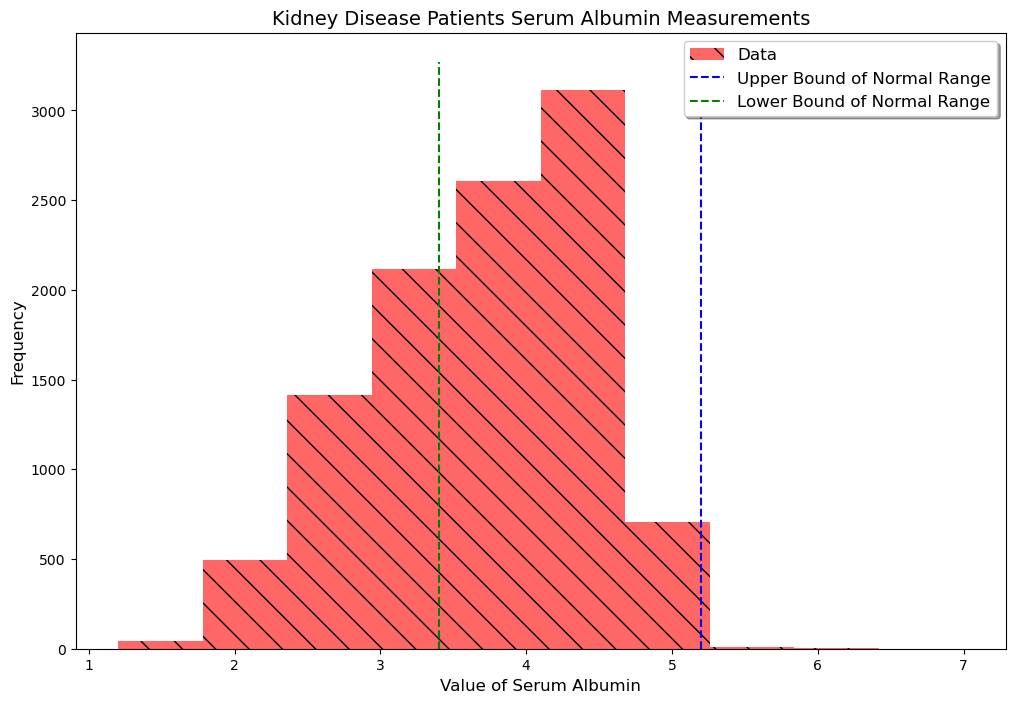

In [106]:
serum_albumin_labs = kidney_disease_df.loc[kidney_disease_df['itemid'] == 50862]
serum_albumin_lb = np.min(serum_albumin_labs['ref_range_lower'])
serum_albumin_ub = np.max(serum_albumin_labs['ref_range_upper'])
plt.figure(figsize = (12, 8))
n, bins, patches = plt.hist(serum_albumin_labs['valuenum'],
                           color = 'red',
                           hatch = '\\',
                           alpha = 0.6, 
                           label = 'Data')
plt.plot([serum_albumin_ub, serum_albumin_ub],
        [0, 1.05*np.max(n)],
        'b--',
        label = 'Upper Bound of Normal Range')
plt.plot([serum_albumin_lb, serum_albumin_lb],
        [0, 1.05*np.max(n)],
        'g--',
        label = 'Lower Bound of Normal Range')
plt.xlabel('Value of Serum Albumin',
          fontsize = 12)
plt.ylabel('Frequency',
          fontsize = 12)
plt.title('Kidney Disease Patients Serum Albumin Measurements', 
         fontsize = 14)
plt.legend(loc = 'upper right',
          fancybox = True,
          shadow = True,
          fontsize = 12)
plt.show()


In [112]:
n_low_labs = serum_albumin_labs.loc[serum_albumin_labs['valuenum'] <= serum_albumin_lb].shape[0]
n_labs = serum_albumin_labs.shape[0]
print('Out of all of the serum albumin readings, the proportion of values that are lower than normal is', np.round(n_low_labs/n_labs, 4), '\n')
print('The mean serum albumin reading is', np.round(np.mean(serum_albumin_labs['valuenum']), 4), '\n')
print('The standard deviation of the serum albumin reading is', np.round(np.std(serum_albumin_labs['valuenum']), 4), '\n')
print('The first quartile of the serum albumin readings is', serum_albumin_labs['valuenum'].quantile(0.25), '\n')
print('The second quartile of the serum albumin readings is', serum_albumin_labs['valuenum'].quantile(0.5), '\n')
print('The third quartile of the serum albumin readings is', serum_albumin_labs['valuenum'].quantile(0.75))

Out of all of the serum albumin readings, the proportion of values that are lower than normal is 0.3466 

The mean serum albumin reading is 3.6818 

The standard deviation of the serum albumin reading is 0.7375 

The first quartile of the serum albumin readings is 3.2 

The second quartile of the serum albumin readings is 3.8 

The third quartile of the serum albumin readings is 4.2


The histogram shown above indicates that many of the serum albumin readings fall within the normal range. However, there is also a significant portion of the readings that are abnormally low (i.e. lower than 3.4). Very few of the readings are abnormally high. These abnormalities are consistent with our hypothesis. Regarding the summary statistics, roughly $35\%$ of the serum albumin readings are abnormally low. Although this is not an alarmingly high rate, it is significant enough to warrant attention. The other summary statistics are also consistent with our hypothesis. 